# GGSS-R Scheduled Guidance Experiment

# Cell 1: Project layout

In [1]:
from pathlib import Path
import os, sys

PROJECT_ROOT = (Path.cwd() / "GGSS_R_scheduled_guidance_experiment").resolve()
REPO_ROOT = PROJECT_ROOT / "repo"
RESULTS_ROOT = PROJECT_ROOT / "results"
MODEL_STATE_ROOT = PROJECT_ROOT / "model_state"
DATA_ROOT = PROJECT_ROOT / "data"
TARGET_DIR = DATA_ROOT / "samples" / "celeba_target"
TARGET_PATH = TARGET_DIR / "target_0000.png"

for p in [REPO_ROOT, RESULTS_ROOT, MODEL_STATE_ROOT, DATA_ROOT, TARGET_DIR]:
    p.mkdir(parents=True, exist_ok=True)

CODE_ROOT = str(REPO_ROOT)
if CODE_ROOT not in sys.path:
    sys.path.insert(0, CODE_ROOT)

print("Project root :", PROJECT_ROOT)
print("Repository   :", REPO_ROOT)
print("Results      :", RESULTS_ROOT)
print("Model state  :", MODEL_STATE_ROOT)
print("Data         :", DATA_ROOT)

Project root : /content/GGSS_R_scheduled_guidance_experiment
Repository   : /content/GGSS_R_scheduled_guidance_experiment/repo
Results      : /content/GGSS_R_scheduled_guidance_experiment/results
Model state  : /content/GGSS_R_scheduled_guidance_experiment/model_state
Data         : /content/GGSS_R_scheduled_guidance_experiment/data


# Cell 2: Clone + extract authors’ repo

In [2]:
import shutil, subprocess, zipfile

REPO_URL = "https://github.com/mjyyhhxx/GGSS-R.git"
runner_path = REPO_ROOT / "sample_condition_same_inputs.py"

if runner_path.is_file():
    print("✓ Repository already present")
else:
    if REPO_ROOT.exists():
        shutil.rmtree(REPO_ROOT)
    print("Cloning GGSS-R repository...")
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(REPO_ROOT)], check=True)

    code_zip = REPO_ROOT / "code.zip"
    assert code_zip.is_file(), f"code.zip not found at {code_zip}"
    print("Extracting code.zip...")
    with zipfile.ZipFile(code_zip, "r") as z:
        z.extractall(REPO_ROOT)

    extracted = REPO_ROOT / "code"
    if extracted.is_dir():
        for item in extracted.iterdir():
            dest = REPO_ROOT / item.name
            if dest.exists():
                if dest.is_dir():
                    shutil.rmtree(dest)
                else:
                    dest.unlink()
            shutil.move(str(item), str(dest))
        extracted.rmdir()

    assert (REPO_ROOT / "sample_condition_same_inputs.py").is_file()
    print("✓ Repository cloned and extracted")

os.chdir(CODE_ROOT)
if CODE_ROOT not in sys.path:
    sys.path.insert(0, CODE_ROOT)

try:
    commit = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=CODE_ROOT, text=True).strip()
    (PROJECT_ROOT / "AUTHOR_REPO_COMMIT.txt").write_text(commit + "\n")
    print("Author repo commit:", commit)
except Exception as e:
    print("⚠ Could not record Git commit:", e)

print("Working dir:", os.getcwd())
print("Top-level:", sorted(os.listdir(CODE_ROOT))[:20])

Cloning GGSS-R repository...
Extracting code.zip...
✓ Repository cloned and extracted
Author repo commit: b337ef1192f3a04a776042882a2d636724817775
Working dir: /content/GGSS_R_scheduled_guidance_experiment/repo
Top-level: ['.DS_Store', '.git', 'README.md', 'RV', '__MACOSX', 'code.zip', 'configs', 'data', 'guided_diffusion', 'models', 'results', 'sample_condition_same_inputs.py', 'util', 'x_0000.png']


# Cell 3: Integrity checks

In [3]:
required = [
    "sample_condition_same_inputs.py",
    "guided_diffusion/condition_methods.py",
    "guided_diffusion/measurements.py",
    "guided_diffusion/gaussian_diffusion.py",
    "guided_diffusion/attacked_model.py",
    "configs/model_config.yaml",
    "configs/diffusion_ddim1000_config.yaml",
    "configs/reconstruction_config.yaml",
]
print("Working directory:", os.getcwd())
for rel in required:
    path = os.path.join(CODE_ROOT, rel)
    ok = os.path.isfile(path)
    print(f"{'✓' if ok else '✗'} {rel}")
    assert ok, f"Missing: {path}"

cond_src = (REPO_ROOT / "guided_diffusion" / "condition_methods.py").read_text()
assert "class GSS" in cond_src and "mix_direction" in cond_src, "GSS class / mixing formula missing"
runner_src = (REPO_ROOT / "sample_condition_same_inputs.py").read_text()
assert "y_n = y  #+ gaussian_noise" in runner_src or "y_n = y #+ gaussian_noise" in runner_src, \
    "Expected commented-out noise line not found"
print("\n✓ Repository integrity + content checks passed")

Working directory: /content/GGSS_R_scheduled_guidance_experiment/repo
✓ sample_condition_same_inputs.py
✓ guided_diffusion/condition_methods.py
✓ guided_diffusion/measurements.py
✓ guided_diffusion/gaussian_diffusion.py
✓ guided_diffusion/attacked_model.py
✓ configs/model_config.yaml
✓ configs/diffusion_ddim1000_config.yaml
✓ configs/reconstruction_config.yaml

✓ Repository integrity + content checks passed


# Cell 4: Dependencies + CUDA

In [4]:
import subprocess, sys, torch
packages = ["lpips", "gdown", "pyyaml", "tqdm", "matplotlib", "pillow", "pandas"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + packages)

assert torch.cuda.is_available(), "A CUDA-capable GPU is required."
DEVICE = torch.device("cuda:0")
print("PyTorch:", torch.__version__)
print("CUDA   :", torch.version.cuda)
print("GPU    :", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA   : 12.8
GPU    : Tesla T4


# Cell 5: Download FFHQ checkpoint

In [5]:
import hashlib, shutil
import gdown
from pathlib import Path

DPS_FOLDER_URL = "https://drive.google.com/drive/folders/1jElnRoFv7b31fG0v6pTSQkelbSX3xGZh"
DPS_DOWNLOAD_DIR = PROJECT_ROOT / "dps-checkpoint"
MODEL_DIR = REPO_ROOT / "models"
MODEL_PATH = MODEL_DIR / "ffhq_10m.pt"
DPS_DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

source = DPS_DOWNLOAD_DIR / "ffhq_10m.pt"
if not source.is_file():
    print("Inspecting public DPS checkpoint folder...")
    manifest = gdown.download_folder(
        url=DPS_FOLDER_URL,
        output=str(DPS_DOWNLOAD_DIR),
        quiet=True,
        use_cookies=False,
        remaining_ok=True,
        skip_download=True,
    )
    ffhq_entries = [e for e in manifest if Path(e.path).name == "ffhq_10m.pt"]
    if len(ffhq_entries) != 1:
        raise RuntimeError(f"Expected exactly one ffhq_10m.pt; found {len(ffhq_entries)}")
    print("Downloading ffhq_10m.pt only...")
    gdown.download(id=ffhq_entries[0].id, output=str(source), quiet=False, use_cookies=False)

sha = hashlib.sha256()
with source.open("rb") as f:
    for chunk in iter(lambda: f.read(1 << 20), b""):
        sha.update(chunk)
print("Checkpoint:", source)
print("Size (MiB):", source.stat().st_size / 1024**2)
print("SHA256    :", sha.hexdigest())
_ = torch.load(source, map_location="cpu")
if source.resolve() != MODEL_PATH.resolve():
    shutil.copy2(source, MODEL_PATH)
print("Installed at:", MODEL_PATH)

Inspecting public DPS checkpoint folder...


Downloading...
From (original): https://drive.google.com/uc?id=1BGwhRWUoguF-D8wlZ65tf227gp3cDUDh
From (redirected): https://drive.google.com/uc?id=1BGwhRWUoguF-D8wlZ65tf227gp3cDUDh&confirm=t&uuid=1fe72c95-40ef-4825-a9d6-935e1c13003e
To: /content/GGSS_R_scheduled_guidance_experiment/dps-checkpoint/ffhq_10m.pt
100%|██████████| 374M/374M [00:06<00:00, 60.7MB/s]


Checkpoint: /content/GGSS_R_scheduled_guidance_experiment/dps-checkpoint/ffhq_10m.pt
Size (MiB): 357.0726709365845
SHA256    : 81d535743156ec6be34d8668e6920da94f0614074d7793a16c8fa9e306237faa
Installed at: /content/GGSS_R_scheduled_guidance_experiment/repo/models/ffhq_10m.pt


# Cell 6: Download single target image

In [6]:
TARGET_FOLDER_URL = "https://drive.google.com/drive/folders/1F4XfOcgolj4cGUQd99mPflK1mg6zhdaw?usp=sharing"
TARGET_DOWNLOAD_DIR = PROJECT_ROOT / "target-download"
TARGET_DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

if not TARGET_PATH.is_file():
    print("Downloading target folder...")
    gdown.download_folder(
        url=TARGET_FOLDER_URL,
        output=str(TARGET_DOWNLOAD_DIR),
        quiet=False,
        use_cookies=False,
        remaining_ok=True,
    )
    candidates = list(TARGET_DOWNLOAD_DIR.rglob("target_0000.png"))
    if not candidates:
        raise RuntimeError("target_0000.png not found after download")
    shutil.copy2(candidates[0], TARGET_PATH)
    print("Copied to", TARGET_PATH)
else:
    print("✓ Target already present:", TARGET_PATH)

from PIL import Image
img = Image.open(TARGET_PATH).convert("RGB")
print("Original size:", img.size)
print("Mode:", img.mode)

Retrieving folder contents


Processing file 1tWp__4sas9i4YRxKaFt3haPMQcsQPLvL target_0000.png


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1tWp__4sas9i4YRxKaFt3haPMQcsQPLvL
To: /content/GGSS_R_scheduled_guidance_experiment/target-download/target_0000.png
100%|██████████| 56.7k/56.7k [00:00<00:00, 10.9MB/s]

Copied to /content/GGSS_R_scheduled_guidance_experiment/data/samples/celeba_target/target_0000.png
Original size: (178, 218)
Mode: RGB



Download completed


# Cell 7: Three I/O patches

In [7]:
import re, shutil
from pathlib import Path

# Patch 1 – runner mkdir
RUNNER_PATH = REPO_ROOT / "sample_condition_same_inputs.py"
backup = RUNNER_PATH.with_suffix(".py.bak_io1")
if not backup.exists():
    shutil.copy2(RUNNER_PATH, backup)

text = RUNNER_PATH.read_text()
old = """        sample, distance_list = sample_fn(x_start=x_start, measurement=y_n, record=True,
                                          save_root=os.path.join(out_path, 'progresss', str(i).zfill(5)))"""
new = """        progress_dir = os.path.join(
            out_path,
            'progresss',
            str(i).zfill(5)
        )
        os.makedirs(progress_dir, exist_ok=True)

        sample, distance_list = sample_fn(
            x_start=x_start,
            measurement=y_n,
            record=True,
            save_root=progress_dir
        )"""
if "os.makedirs(progress_dir, exist_ok=True)" not in text:
    if old not in text:
        print("⚠ Runner progresss block not found in exact form (non-fatal for direct orchestration)")
    else:
        text = text.replace(old, new, 1)
        RUNNER_PATH.write_text(text)
        print("✓ Patch 1 (runner mkdir) applied")
else:
    print("✓ Patch 1 already present")

# Patch 2 – x0 path + mkdir
GD_PATH = REPO_ROOT / "guided_diffusion" / "gaussian_diffusion.py"
backup2 = GD_PATH.with_suffix(".py.bak_io2")
if not backup2.exists():
    shutil.copy2(GD_PATH, backup2)

text = GD_PATH.read_text()
old = '''                x0_file_path = os.path.join('code/results/reconstruction/progress/x0', f"x_{str(idx).zfill(4)}.png")
                plt.imsave(file_path, clear_color(img))
                plt.imsave(x0_file_path, clear_color(out['pred_xstart']) )'''
new = '''                x0_file_path = os.path.join(save_root, 'x0', f"x_{str(idx).zfill(4)}.png")
                os.makedirs(os.path.dirname(x0_file_path), exist_ok=True)
                plt.imsave(file_path, clear_color(img))
                plt.imsave(x0_file_path, clear_color(out['pred_xstart']) )'''
if "os.makedirs(os.path.dirname(x0_file_path), exist_ok=True)" not in text:
    if old not in text:
        print("⚠ x0 path block not found in exact form; sparse patch will handle it")
    else:
        text = text.replace(old, new, 1)
        GD_PATH.write_text(text)
        print("✓ Patch 2 (x0 path + mkdir) applied")
else:
    print("✓ Patch 2 already present")

# Patch 3 – sparse snapshots
text = GD_PATH.read_text()
match = re.search(r"(if record:.*?)(?=\n\s*return img, distance_list)", text, re.DOTALL)
if match is None:
    raise RuntimeError("Could not locate the 'if record:' block")
if "if record and (idx % 100 == 0 or idx == 0):" not in text:
    new_block = '''if record and (idx % 100 == 0 or idx == 0):
                file_path = os.path.join(save_root, f"x_{str(idx).zfill(4)}.png")
                x0_file_path = os.path.join(save_root, "x0", f"x_{str(idx).zfill(4)}.png")
                os.makedirs(os.path.dirname(x0_file_path), exist_ok=True)
                plt.imsave(file_path, clear_color(img))
                plt.imsave(x0_file_path, clear_color(out['pred_xstart']))
'''
    text = text[:match.start(1)] + new_block + text[match.end(1):]
    GD_PATH.write_text(text)
    print("✓ Patch 3 (sparse snapshots) applied")
else:
    print("✓ Patch 3 already present")

print("\nI/O patches finished.")

✓ Patch 1 (runner mkdir) applied
✓ Patch 2 (x0 path + mkdir) applied
✓ Patch 3 (sparse snapshots) applied

I/O patches finished.


# Cell 8: Two additive hooks

In [8]:
# Hook 1 – GSS accepts optional guidance_schedule_fn(idx)
COND_PATH = REPO_ROOT / "guided_diffusion" / "condition_methods.py"
backup_c = COND_PATH.with_suffix(".py.bak_hook")
if not backup_c.exists():
    shutil.copy2(COND_PATH, backup_c)

text = COND_PATH.read_text()

if "guidance_schedule_fn" not in text:
    old_init = '''    def __init__(self, operator, noiser, **kwargs):
        super().__init__(operator, noiser)
        self.interval = kwargs.get('interval', 1.)
        self.guidance_scale = kwargs.get('guidance_scale', 1.)
        print(f'interval: {self.interval}')
        print(f'guidance_scale: {self.guidance_scale}')'''
    new_init = '''    def __init__(self, operator, noiser, **kwargs):
        super().__init__(operator, noiser)
        self.interval = kwargs.get('interval', 1.)
        self.guidance_scale = kwargs.get('guidance_scale', 1.)
        self.guidance_schedule_fn = kwargs.get('guidance_schedule_fn', None)
        print(f'interval: {self.interval}')
        print(f'guidance_scale: {self.guidance_scale}')
        if self.guidance_schedule_fn is not None:
            print('guidance_schedule_fn: enabled')'''

    old_rate = '''            guidance_rate = self.guidance_scale'''
    new_rate = '''            if self.guidance_schedule_fn is not None:
                guidance_rate = float(self.guidance_schedule_fn(idx))
            else:
                guidance_rate = self.guidance_scale'''

    if old_init not in text or old_rate not in text:
        raise RuntimeError("Could not locate expected GSS fragments for the schedule hook")
    text = text.replace(old_init, new_init, 1)
    text = text.replace(old_rate, new_rate, 1)
    COND_PATH.write_text(text)
    print("✓ Hook 1 (GSS guidance_schedule_fn) applied")
else:
    print("✓ Hook 1 already present")

# Hook 2 – p_sample_loop accepts optional step_callback
text = GD_PATH.read_text()
if "step_callback" not in text:
    old_sig = '''    def p_sample_loop(self,
                      model,
                      x_start,
                      measurement,
                      measurement_cond_fn,
                      record,
                      save_root,
                      use_shortcut,
                      shortcut_start_time):'''
    new_sig = '''    def p_sample_loop(self,
                      model,
                      x_start,
                      measurement,
                      measurement_cond_fn,
                      record,
                      save_root,
                      use_shortcut,
                      shortcut_start_time,
                      step_callback=None):'''

    old_call = '''            img, distance = measurement_cond_fn(x_t=out['sample'],
                                                x_t_mean=out['mean'],
                                                idx=idx,
                                      measurement=measurement,
                                      noisy_measurement=noisy_measurement,
                                      x_prev=img,
                                      x_0_hat=out['pred_xstart'],
                                      sigma_t=out['sigma_t'],
                                      func=out['func'])
            # r_list.append(r.item())
            distance_list.append(distance.item())'''
    new_call = '''            img, distance = measurement_cond_fn(x_t=out['sample'],
                                                x_t_mean=out['mean'],
                                                idx=idx,
                                      measurement=measurement,
                                      noisy_measurement=noisy_measurement,
                                      x_prev=img,
                                      x_0_hat=out['pred_xstart'],
                                      sigma_t=out['sigma_t'],
                                      func=out['func'])
            # r_list.append(r.item())
            distance_list.append(distance.item())
            if step_callback is not None:
                step_callback(idx, out['pred_xstart'].detach(), img.detach())'''

    if old_sig not in text or old_call not in text:
        raise RuntimeError("Could not locate expected p_sample_loop fragments for the callback hook")
    text = text.replace(old_sig, new_sig, 1)
    text = text.replace(old_call, new_call, 1)
    GD_PATH.write_text(text)
    print("✓ Hook 2 (p_sample_loop step_callback) applied")
else:
    print("✓ Hook 2 already present")

print("\nAll patches and hooks applied successfully.")

✓ Hook 1 (GSS guidance_schedule_fn) applied
✓ Hook 2 (p_sample_loop step_callback) applied

All patches and hooks applied successfully.


# Cell 9: Untrained victim (MLP_1) with fixed seed

In [9]:
import torch.nn as nn
from guided_diffusion.attacked_model import MLP_1

SEED_VICTIM = 42
torch.manual_seed(SEED_VICTIM)
torch.cuda.manual_seed_all(SEED_VICTIM)

victim = MLP_1().to(DEVICE)
victim.eval()

num_params = sum(p.numel() for p in victim.parameters())
print(f"Model: MLP_1  |  parameters: {num_params:,}")
assert num_params == 100729730, f"Unexpected parameter count: {num_params}"

MODEL_STATE_PATH = MODEL_STATE_ROOT / "MLP_1.pth"
torch.save(victim.state_dict(), MODEL_STATE_PATH)

default_state = REPO_ROOT / "model_state" / "MLP_1.pth"
default_state.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(MODEL_STATE_PATH, default_state)

print("Saved victim state_dict to", MODEL_STATE_PATH)
print("Also copied to", default_state)

Model: MLP_1  |  parameters: 100,729,730
Saved victim state_dict to /content/GGSS_R_scheduled_guidance_experiment/model_state/MLP_1.pth
Also copied to /content/GGSS_R_scheduled_guidance_experiment/repo/model_state/MLP_1.pth


# Cell 10: Target + noisy measurement

In [10]:
!pip -q install opacus
import opacus
print("Opacus version:", opacus.__version__)
from opacus.grad_sample import GradSampleModule
print("✓ GradSampleModule import succeeded.")

from torchvision import transforms
from guided_diffusion.measurements import get_operator, get_noise

preprocess = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

target_pil = Image.open(TARGET_PATH).convert("RGB")
target = preprocess(target_pil).unsqueeze(0).to(DEVICE)
print("Target tensor shape:", tuple(target.shape))
print("Target range: [{:.3f}, {:.3f}]".format(target.min().item(), target.max().item()))

operator = get_operator(name="reconstruction", device=DEVICE)

with torch.enable_grad():
    y_clean = operator.forward(target)
print("Clean gradient shape:", tuple(y_clean.shape))

NOISE_VARIANCE = 0.01
torch.manual_seed(12345)
noise = torch.randn_like(y_clean) * (NOISE_VARIANCE ** 0.5)
y_n = (y_clean + noise).detach()

print(f"Noise variance: {NOISE_VARIANCE}")
print(f"||y_clean|| = {y_clean.norm().item():.4f}")
print(f"||noise||   = {noise.norm().item():.4f}")
print(f"||y_n||     = {y_n.norm().item():.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.9/308.9 kB 9.3 MB/s eta 0:00:00
Opacus version: 1.6.0
✓ GradSampleModule import succeeded.
Target tensor shape: (1, 3, 256, 256)
Target range: [-1.000, 1.000]
Clean gradient shape: (100729730,)
Noise variance: 0.01
||y_clean|| = 21.9046
||noise||   = 1003.6783
||y_n||     = 1003.9185


# Cell 11: Metric helpers

In [11]:
import lpips
import numpy as np

lpips_fn = lpips.LPIPS(net="vgg").to(DEVICE).eval()

def to_01(x):
    """Fixed linear decode from [-1,1] → [0,1]. Never adaptive."""
    return (x * 0.5 + 0.5).clamp(0.0, 1.0)

def mse_psnr(pred, target):
    p = to_01(pred)
    t = to_01(target)
    mse = torch.mean((p - t) ** 2).item()
    psnr = 10.0 * np.log10(1.0 / (mse + 1e-12))
    return mse, psnr

@torch.no_grad()
def compute_lpips(pred, target):
    return lpips_fn(pred, target).item()

print("Metric helpers ready (MSE/PSNR on [0,1], LPIPS net=vgg).")

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 80.3MB/s]


Loading model from: /usr/local/lib/python3.13/dist-packages/lpips/weights/v0.1/vgg.pth
Metric helpers ready (MSE/PSNR on [0,1], LPIPS net=vgg).


# Cell 12: Load diffusion model & sampler

In [12]:
import yaml
from guided_diffusion.unet import create_model
from guided_diffusion.gaussian_diffusion import create_sampler
from guided_diffusion.condition_methods import get_conditioning_method

def load_yaml(p):
    with open(p) as f:
        return yaml.load(f, Loader=yaml.FullLoader)

model_cfg = load_yaml(REPO_ROOT / "configs" / "model_config.yaml")
diff_cfg  = load_yaml(REPO_ROOT / "configs" / "diffusion_ddim1000_config.yaml")
model_cfg["model_path"] = str(MODEL_PATH)

diffusion_model = create_model(**model_cfg)
diffusion_model = diffusion_model.to(DEVICE).eval()
print("Diffusion model loaded.")

sampler = create_sampler(**diff_cfg)
print("Sampler:", type(sampler).__name__, "| timesteps:", sampler.num_timesteps)

Diffusion model loaded.
eta: 1
Sampler: DDIM | timesteps: 1000


# Cell 13: Conditions + shared x_T

In [13]:
GUIDANCE_STATIC = 0.2
N_STEPS = 1000

def linear_schedule(idx):
    """m_r(idx) = 0.2 * idx / 999  (idx runs 999 → 0)"""
    return GUIDANCE_STATIC * (idx / (N_STEPS - 1))

assert abs(linear_schedule(999) - 0.2) < 1e-9
assert abs(linear_schedule(0)   - 0.0) < 1e-9
print("Schedule endpoints OK: m_r(999)=0.2, m_r(0)=0.0")

SEED_XT = 2024
torch.manual_seed(SEED_XT)
torch.cuda.manual_seed_all(SEED_XT)
x_T = torch.randn(1, 3, 256, 256, device=DEVICE)
print("Shared x_T norm:", x_T.norm().item())

Schedule endpoints OK: m_r(999)=0.2, m_r(0)=0.0
Shared x_T norm: 443.81463623046875


# Cell 14: Reconstruction runner

In [14]:
from functools import partial
import time
from collections import defaultdict

def run_one_condition(name, guidance_scale=None, guidance_schedule_fn=None, save_subdir=None):
    assert (guidance_scale is None) ^ (guidance_schedule_fn is None), \
        "Provide exactly one of guidance_scale or guidance_schedule_fn"

    out_dir = RESULTS_ROOT / (save_subdir or name)
    out_dir.mkdir(parents=True, exist_ok=True)
    (out_dir / "x0").mkdir(exist_ok=True)

    cond_kwargs = dict(
        interval=1,
        guidance_scale=guidance_scale if guidance_scale is not None else 0.0,
    )
    if guidance_schedule_fn is not None:
        cond_kwargs["guidance_schedule_fn"] = guidance_schedule_fn

    noiser = get_noise(name="clean")
    cond_method = get_conditioning_method("GSS", operator, noiser, **cond_kwargs)
    measurement_cond_fn = cond_method.conditioning

    history = defaultdict(list)

    def step_callback(idx, pred_x0, x_t):
        mse, psnr = mse_psnr(pred_x0, target)
        lp = compute_lpips(pred_x0, target)
        mr = float(guidance_schedule_fn(idx)) if guidance_schedule_fn is not None else float(guidance_scale)
        history["idx"].append(idx)
        history["mse"].append(mse)
        history["psnr"].append(psnr)
        history["lpips"].append(lp)
        history["mr"].append(mr)
        if idx % 100 == 0 or idx == 0:
            print(f"  [{name}] idx={idx:4d}  m_r={mr:.4f}  MSE={mse:.6f}  PSNR={psnr:.2f}  LPIPS={lp:.6f}")

    torch.manual_seed(SEED_XT)
    torch.cuda.manual_seed_all(SEED_XT)
    x_start = x_T.clone().requires_grad_()

    t0 = time.time()
    sample, distance_list = sampler.p_sample_loop(
        model=diffusion_model,
        x_start=x_start,
        measurement=y_n,
        measurement_cond_fn=measurement_cond_fn,
        record=True,
        save_root=str(out_dir),
        use_shortcut=False,
        shortcut_start_time=400,
        step_callback=step_callback,
    )
    elapsed = time.time() - t0
    print(f"[{name}] finished in {elapsed/60:.1f} min")

    final_mse, final_psnr = mse_psnr(sample, target)
    final_lpips = compute_lpips(sample, target)

    mse_arr   = np.array(history["mse"])
    psnr_arr  = np.array(history["psnr"])
    lpips_arr = np.array(history["lpips"])
    idx_arr   = np.array(history["idx"])

    return {
        "name": name,
        "history": dict(history),
        "final": {"mse": final_mse, "psnr": final_psnr, "lpips": final_lpips},
        "peak": {
            "mse":   {"value": float(mse_arr.min()),   "idx": int(idx_arr[np.argmin(mse_arr)])},
            "psnr":  {"value": float(psnr_arr.max()),  "idx": int(idx_arr[np.argmax(psnr_arr)])},
            "lpips": {"value": float(lpips_arr.min()), "idx": int(idx_arr[np.argmin(lpips_arr)])},
        },
        "sample": sample.detach().cpu(),
        "elapsed_sec": elapsed,
        "out_dir": str(out_dir),
    }

# Cell 15: Run both conditions

In [15]:
print("="*70)
print("STATIC guidance (m_r = 0.2 constant)")
print("="*70)
res_static = run_one_condition(
    name="static_0.2",
    guidance_scale=0.2,
    guidance_schedule_fn=None,
    save_subdir="static_0.2",
)

print("\n" + "="*70)
print("SCHEDULED guidance (linear decay 0.2 → 0.0)")
print("="*70)
res_sched = run_one_condition(
    name="scheduled_linear",
    guidance_scale=None,
    guidance_schedule_fn=linear_schedule,
    save_subdir="scheduled_linear",
)

STATIC guidance (m_r = 0.2 constant)
interval: 1
guidance_scale: 0.2


  0%|          | 0/1000 [00:00<?, ?it/s]

  [static_0.2] idx= 900  m_r=0.2000  MSE=0.156442  PSNR=8.06  LPIPS=0.916578
  [static_0.2] idx= 800  m_r=0.2000  MSE=0.155402  PSNR=8.09  LPIPS=0.918308
  [static_0.2] idx= 700  m_r=0.2000  MSE=0.169573  PSNR=7.71  LPIPS=0.928060
  [static_0.2] idx= 600  m_r=0.2000  MSE=0.175313  PSNR=7.56  LPIPS=0.946046
  [static_0.2] idx= 500  m_r=0.2000  MSE=0.155268  PSNR=8.09  LPIPS=0.936914
  [static_0.2] idx= 400  m_r=0.2000  MSE=0.149089  PSNR=8.27  LPIPS=0.946231
  [static_0.2] idx= 300  m_r=0.2000  MSE=0.132521  PSNR=8.78  LPIPS=0.936826
  [static_0.2] idx= 200  m_r=0.2000  MSE=0.122326  PSNR=9.12  LPIPS=0.934159
  [static_0.2] idx= 100  m_r=0.2000  MSE=0.115801  PSNR=9.36  LPIPS=0.930837
  [static_0.2] idx=   0  m_r=0.2000  MSE=0.108650  PSNR=9.64  LPIPS=0.931672
[static_0.2] finished in 24.7 min

SCHEDULED guidance (linear decay 0.2 → 0.0)
interval: 1
guidance_scale: 0.0
guidance_schedule_fn: enabled


  0%|          | 0/1000 [00:00<?, ?it/s]

  [scheduled_linear] idx= 900  m_r=0.1802  MSE=0.145477  PSNR=8.37  LPIPS=0.903606

  [scheduled_linear] idx= 800  m_r=0.1602  MSE=0.146666  PSNR=8.34  LPIPS=0.924903

  [scheduled_linear] idx= 700  m_r=0.1401  MSE=0.172791  PSNR=7.62  LPIPS=0.931949

  [scheduled_linear] idx= 600  m_r=0.1201  MSE=0.164105  PSNR=7.85  LPIPS=0.934600

  [scheduled_linear] idx= 500  m_r=0.1001  MSE=0.114276  PSNR=9.42  LPIPS=0.921820

  [scheduled_linear] idx= 400  m_r=0.0801  MSE=0.087803  PSNR=10.56  LPIPS=0.909353

  [scheduled_linear] idx= 300  m_r=0.0601  MSE=0.078257  PSNR=11.06  LPIPS=0.913227

  [scheduled_linear] idx= 200  m_r=0.0400  MSE=0.065857  PSNR=11.81  LPIPS=0.890467

  [scheduled_linear] idx= 100  m_r=0.0200  MSE=0.057324  PSNR=12.42  LPIPS=0.876913

  [scheduled_linear] idx=   0  m_r=0.0000  MSE=0.054847  PSNR=12.61  LPIPS=0.874449
[scheduled_linear] finished in 24.6 min


# Cell 16: Summary table

In [16]:
import pandas as pd
from IPython.display import display

rows = []
for res in [res_static, res_sched]:
    rows.append({
        "condition": res["name"],
        "peak_MSE":   f"{res['peak']['mse']['value']:.6f} @ idx={res['peak']['mse']['idx']}",
        "peak_PSNR":  f"{res['peak']['psnr']['value']:.2f} @ idx={res['peak']['psnr']['idx']}",
        "peak_LPIPS": f"{res['peak']['lpips']['value']:.6f} @ idx={res['peak']['lpips']['idx']}",
        "final_MSE":  f"{res['final']['mse']:.6f}",
        "final_PSNR": f"{res['final']['psnr']:.2f}",
        "final_LPIPS":f"{res['final']['lpips']:.6f}",
        "time_min":   f"{res['elapsed_sec']/60:.1f}",
    })

df = pd.DataFrame(rows)
print("\n=== Summary (lower MSE/LPIPS better, higher PSNR better) ===")
display(df)
df.to_csv(RESULTS_ROOT / "summary_table.csv", index=False)
print("Saved →", RESULTS_ROOT / "summary_table.csv")

print("\n--- Peak quality comparison ---")
for metric, higher_better in [("mse", False), ("psnr", True), ("lpips", False)]:
    s = res_static["peak"][metric]["value"]
    c = res_sched["peak"][metric]["value"]
    better = "scheduled" if (c > s if higher_better else c < s) else "static"
    print(f"  peak {metric.upper():5s}: static={s:.6f}  scheduled={c:.6f}  → better: {better}")

print("\n--- Final quality comparison ---")
for metric, higher_better in [("mse", False), ("psnr", True), ("lpips", False)]:
    s = res_static["final"][metric]
    c = res_sched["final"][metric]
    better = "scheduled" if (c > s if higher_better else c < s) else "static"
    print(f"  final {metric.upper():5s}: static={s:.6f}  scheduled={c:.6f}  → better: {better}")


=== Summary (lower MSE/LPIPS better, higher PSNR better) ===


,condition,peak_MSE,peak_PSNR,peak_LPIPS,final_MSE,final_PSNR,final_LPIPS,time_min
0,static_0.2,0.108650 @ idx=0,9.64 @ idx=0,0.816690 @ idx=999,0.108650,9.64,0.931672,24.7
1,scheduled_linear,0.054847 @ idx=0,12.61 @ idx=0,0.816690 @ idx=999,0.054847,12.61,0.874449,24.6


Saved → /content/GGSS_R_scheduled_guidance_experiment/results/summary_table.csv

--- Peak quality comparison ---
  peak MSE  : static=0.108650  scheduled=0.054847  → better: scheduled
  peak PSNR : static=9.639714  scheduled=12.608503  → better: scheduled
  peak LPIPS: static=0.816690  scheduled=0.816690  → better: static

--- Final quality comparison ---
  final MSE  : static=0.108650  scheduled=0.054847  → better: scheduled
  final PSNR : static=9.639714  scheduled=12.608503  → better: scheduled
  final LPIPS: static=0.931672  scheduled=0.874449  → better: scheduled


# Cell 17: Metric curves

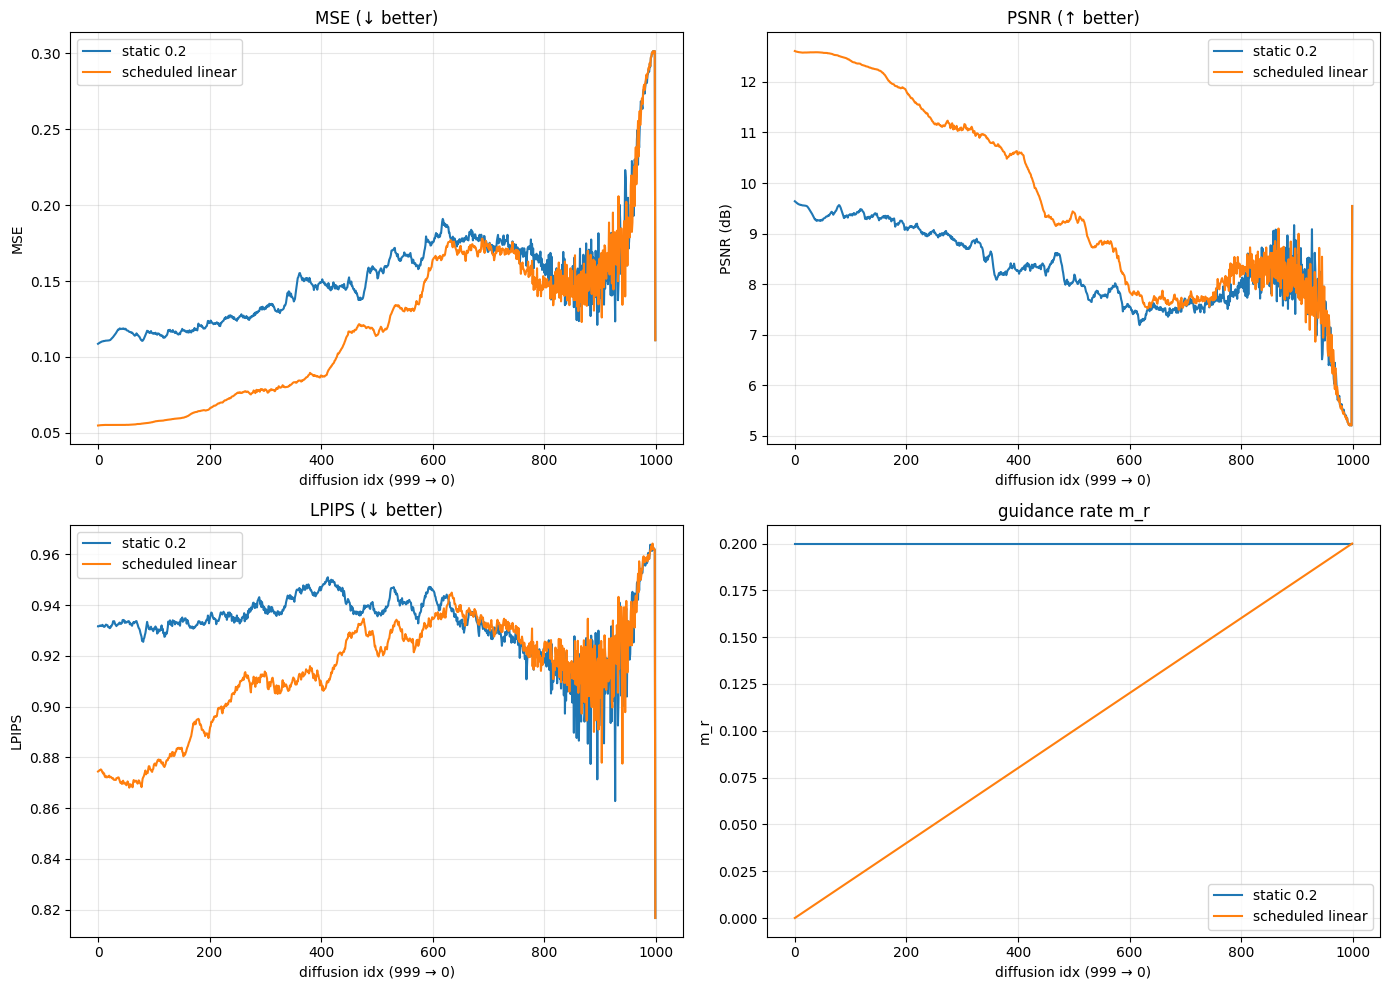

Saved → /content/GGSS_R_scheduled_guidance_experiment/results/metric_curves.png
Saved → /content/GGSS_R_scheduled_guidance_experiment/results/static_0.2_curves.csv
Saved → /content/GGSS_R_scheduled_guidance_experiment/results/scheduled_linear_curves.csv


In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for res, color, label in [(res_static, "C0", "static 0.2"), (res_sched, "C1", "scheduled linear")]:
    h = res["history"]
    order = np.argsort(h["idx"])[::-1]
    xs = np.array(h["idx"])[order]
    axes[0,0].plot(xs, np.array(h["mse"])[order], color=color, label=label)
    axes[0,1].plot(xs, np.array(h["psnr"])[order], color=color, label=label)
    axes[1,0].plot(xs, np.array(h["lpips"])[order], color=color, label=label)
    axes[1,1].plot(xs, np.array(h["mr"])[order], color=color, label=label)

for ax, title, ylabel in zip(
    axes.flat,
    ["MSE (↓ better)", "PSNR (↑ better)", "LPIPS (↓ better)", "guidance rate m_r"],
    ["MSE", "PSNR (dB)", "LPIPS", "m_r"],
):
    ax.set_title(title)
    ax.set_xlabel("diffusion idx (999 → 0)")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = RESULTS_ROOT / "metric_curves.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved →", fig_path)

for res in [res_static, res_sched]:
    csv_path = RESULTS_ROOT / f"{res['name']}_curves.csv"
    pd.DataFrame(res["history"]).to_csv(csv_path, index=False)
    print("Saved →", csv_path)

# Cell 20: Contact sheet: 10 timesteps × 2 methods

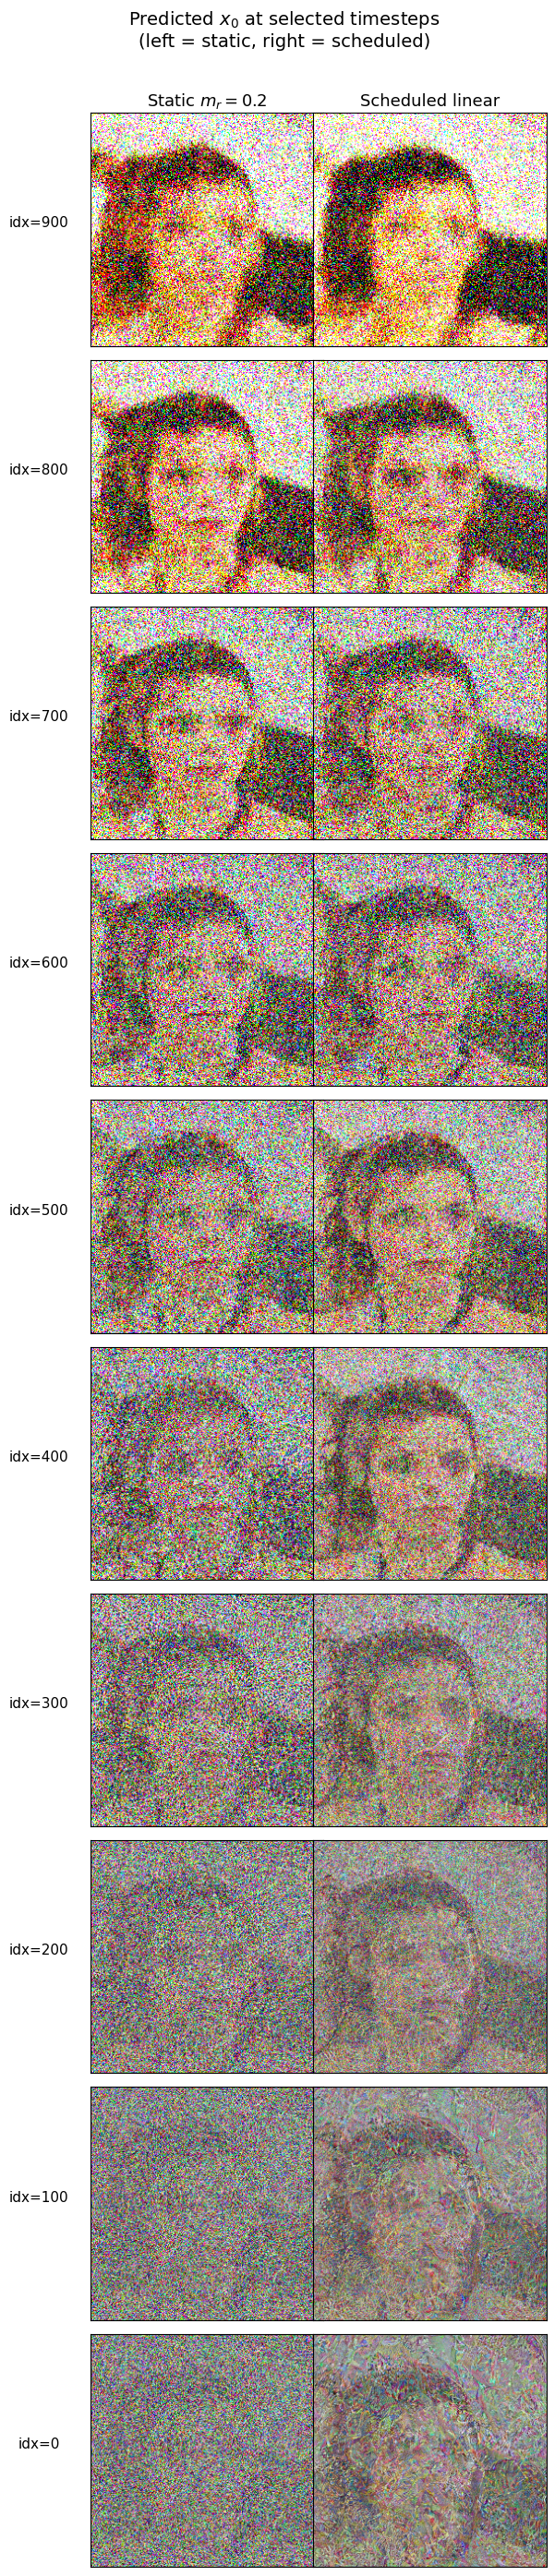

Saved → /content/GGSS_R_scheduled_guidance_experiment/results/contact_sheet_10x2.png


In [ ]:

import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import numpy as np

# Timesteps (matching the sparse saves: every 100 steps + final)
# Going from early (high noise) to late (clean)
desired_idxs = [900, 800, 700, 600, 500, 400, 300, 200, 100, 0]

def load_x0(method_dir, idx):
    """Load the predicted-x0 snapshot closest to the requested idx."""
    path = Path(method_dir) / "x0" / f"x_{idx:04d}.png"
    if path.is_file():
        return np.array(Image.open(path))
    # fallback: try nearest available
    for delta in range(0, 50, 10):
        for candidate in [idx + delta, idx - delta]:
            p = Path(method_dir) / "x0" / f"x_{candidate:04d}.png"
            if p.is_file():
                return np.array(Image.open(p))
    return np.zeros((256, 256, 3), dtype=np.uint8)  # black placeholder

static_dir = RESULTS_ROOT / "static_0.2"
sched_dir  = RESULTS_ROOT / "scheduled_linear"

fig, axes = plt.subplots(10, 2, figsize=(6, 28))

for row, idx in enumerate(desired_idxs):
    # Left column = static
    img_s = load_x0(static_dir, idx)
    axes[row, 0].imshow(img_s)
    axes[row, 0].set_ylabel(f"idx={idx}", fontsize=11, rotation=0, labelpad=40)
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])
    if row == 0:
        axes[row, 0].set_title("Static $m_r=0.2$", fontsize=13)

    # Right column = scheduled
    img_c = load_x0(sched_dir, idx)
    axes[row, 1].imshow(img_c)
    axes[row, 1].set_xticks([])
    axes[row, 1].set_yticks([])
    if row == 0:
        axes[row, 1].set_title("Scheduled linear", fontsize=13)

plt.suptitle("Predicted $x_0$ at selected timesteps\n(left = static, right = scheduled)", fontsize=14, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])
contact_path = RESULTS_ROOT / "contact_sheet_10x2.png"
plt.savefig(contact_path, dpi=140, bbox_inches="tight")
plt.show()
print("Saved →", contact_path)

# Cell 21: Metrics at regular timesteps (every 100 steps)

In [33]:
import pandas as pd
from IPython.display import display

# Desired timesteps (early → late). Change to range(0, 1000, 50) for denser sampling.
CHECKPOINTS = list(range(950, -1, -50))   # 900, 800, ..., 100, 0

def get_metrics_at(history, target_idx):
    """Return (mse, psnr, lpips) for the closest recorded idx."""
    idxs = history["idx"]
    # find closest
    closest = min(range(len(idxs)), key=lambda i: abs(idxs[i] - target_idx))
    return (
        history["mse"][closest],
        history["psnr"][closest],
        history["lpips"][closest],
        idxs[closest],          # actual idx used
    )

rows = []
for idx in CHECKPOINTS:
    mse_s, psnr_s, lpips_s, actual_s = get_metrics_at(res_static["history"], idx)
    mse_c, psnr_c, lpips_c, actual_c = get_metrics_at(res_sched["history"], idx)

    rows.append({
        "requested_idx": idx,
        "actual_idx_static": actual_s,
        "MSE_static": f"{mse_s:.6f}",
        "PSNR_static": f"{psnr_s:.2f}",
        "LPIPS_static": f"{lpips_s:.6f}",
        "actual_idx_sched": actual_c,
        "MSE_sched": f"{mse_c:.6f}",
        "PSNR_sched": f"{psnr_c:.2f}",
        "LPIPS_sched": f"{lpips_c:.6f}",
    })

df_chk = pd.DataFrame(rows)
print("Metrics at selected timesteps (requested every 100 steps)\n")
display(df_chk)

# Also save
out_csv = RESULTS_ROOT / "metrics_at_checkpoints.csv"
df_chk.to_csv(out_csv, index=False)
print("\nSaved →", out_csv)

Metrics at selected timesteps (requested every 100 steps)



,requested_idx,actual_idx_static,MSE_static,PSNR_static,LPIPS_static,actual_idx_sched,MSE_sched,PSNR_sched,LPIPS_sched
0,950,950,0.204827,6.89,0.933699,950,0.191869,7.17,0.931536
1,900,900,0.156442,8.06,0.916578,900,0.145477,8.37,0.903606
2,850,850,0.141535,8.49,0.901646,850,0.139606,8.55,0.911150
3,800,800,0.155402,8.09,0.918308,800,0.146666,8.34,0.924903
4,750,750,0.169982,7.70,0.926842,750,0.164487,7.84,0.928831
5,700,700,0.169573,7.71,0.928060,700,0.172791,7.62,0.931949
6,650,650,0.176519,7.53,0.933990,650,0.173204,7.61,0.940080
7,600,600,0.175313,7.56,0.946046,600,0.164105,7.85,0.934600
8,550,550,0.167760,7.75,0.941176,550,0.130763,8.84,0.926621
9,500,500,0.155268,8.09,0.936914,500,0.114276,9.42,0.921820



Saved → /content/GGSS_R_scheduled_guidance_experiment/results/metrics_at_checkpoints.csv


# Cell 22: Midpoint images (idx = 500)

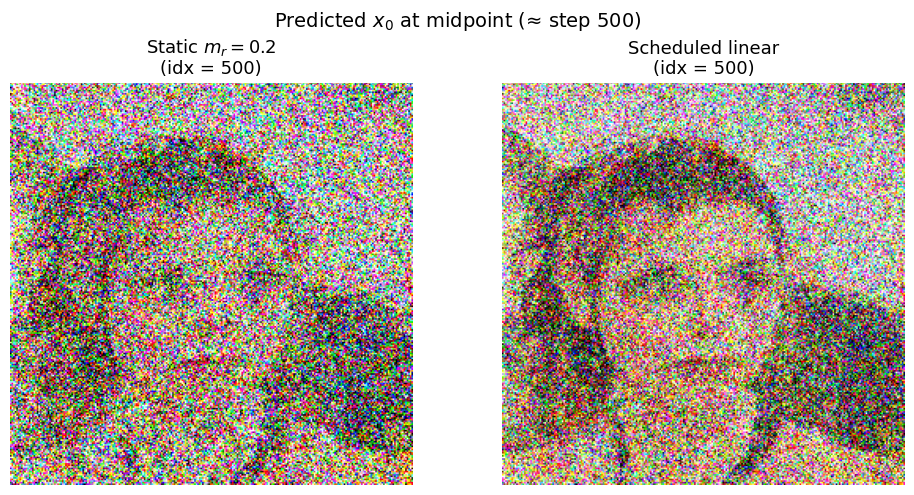

Saved → /content/GGSS_R_scheduled_guidance_experiment/results/midpoint_idx500.png


In [26]:
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

def load_nearest_x0(method_dir, target_idx=500):
    """Load the x0 snapshot closest to target_idx."""
    x0_dir = Path(method_dir) / "x0"
    if not x0_dir.is_dir():
        return None, None

    available = []
    for p in x0_dir.glob("x_*.png"):
        try:
            idx = int(p.stem.split("_")[1])
            available.append((idx, p))
        except:
            continue

    if not available:
        return None, None

    closest_idx, closest_path = min(available, key=lambda t: abs(t[0] - target_idx))
    return closest_idx, Image.open(closest_path)

static_dir = RESULTS_ROOT / "static_0.2"
sched_dir  = RESULTS_ROOT / "scheduled_linear"

idx_s, img_s = load_nearest_x0(static_dir, 500)
idx_c, img_c = load_nearest_x0(sched_dir, 500)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

if img_s is not None:
    axes[0].imshow(img_s)
    axes[0].set_title(f"Static $m_r=0.2$\n(idx = {idx_s})", fontsize=13)
else:
    axes[0].text(0.5, 0.5, "Image not found", ha="center")
    axes[0].set_title("Static $m_r=0.2$")
axes[0].axis("off")

if img_c is not None:
    axes[1].imshow(img_c)
    axes[1].set_title(f"Scheduled linear\n(idx = {idx_c})", fontsize=13)
else:
    axes[1].text(0.5, 0.5, "Image not found", ha="center")
    axes[1].set_title("Scheduled linear")
axes[1].axis("off")

plt.suptitle("Predicted $x_0$ at midpoint (≈ step 500)", fontsize=14)
plt.tight_layout()
mid_path = RESULTS_ROOT / "midpoint_idx500.png"
plt.savefig(mid_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved →", mid_path)

# Cell 23: Final metrics only (idx = 0)

In [27]:
import pandas as pd
from IPython.display import display

final_rows = [
    {
        "condition": "static_0.2",
        "MSE":   res_static["final"]["mse"],
        "PSNR":  res_static["final"]["psnr"],
        "LPIPS": res_static["final"]["lpips"],
    },
    {
        "condition": "scheduled_linear",
        "MSE":   res_sched["final"]["mse"],
        "PSNR":  res_sched["final"]["psnr"],
        "LPIPS": res_sched["final"]["lpips"],
    },
]

df_final = pd.DataFrame(final_rows)
df_final = df_final.set_index("condition")

# nicer formatting
df_display = df_final.copy()
df_display["MSE"]   = df_display["MSE"].map(lambda x: f"{x:.6f}")
df_display["PSNR"]  = df_display["PSNR"].map(lambda x: f"{x:.2f}")
df_display["LPIPS"] = df_display["LPIPS"].map(lambda x: f"{x:.6f}")

print("Final reconstruction metrics (idx = 0)\n")
display(df_display)

# also save raw numbers
df_final.to_csv(RESULTS_ROOT / "final_metrics_idx0.csv")
print("\nSaved →", RESULTS_ROOT / "final_metrics_idx0.csv")

Final reconstruction metrics (idx = 0)



,MSE,PSNR,LPIPS
condition,,,
static_0.2,0.108650,9.64,0.931672
scheduled_linear,0.054847,12.61,0.874449



Saved → /content/GGSS_R_scheduled_guidance_experiment/results/final_metrics_idx0.csv
